# Baseline Experiment: Comparison of supervised and unsupervised CAE

This notebook evaluates only the **baseline experiment**.

It compares the unsupervised and supervised CAE by their performance on the reconstruction and classification task.

In [14]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PATH = "../results/raw_results.json"

sns.set(style="whitegrid")

with open(PATH, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Keep only relevant columns
df_rel = df[[
    "dataset",
    "subset",
    "reconstruction_mse",
    "accuracy"
]]

df_grouped = (
    df_rel
    .groupby(["dataset", "subset"])
    .agg({
        "accuracy": ["mean", "std"],
        "reconstruction_mse": ["mean", "std"]
    })
    .reset_index()
)

# Flatten column names
df_grouped.columns = [
    "dataset", "subset",
    "accuracy_mean", "accuracy_std",
    "reconstruction_mse_mean", "reconstruction_mse_std"
]

# 1) Significance

In [15]:
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon

# pivot so that each seed has one row
acc = df.pivot_table(
    index=["dataset", "seed"],
    columns="subset",
    values="accuracy"
).dropna()

mse = df.pivot_table(
    index=["dataset", "seed"],
    columns="subset",
    values="reconstruction_mse"
).dropna()

# -----------------
# Accuracy
# -----------------
t_acc = ttest_rel(
    acc["supervised_cae"],
    acc["unsupervised_cae"]
)

w_acc = wilcoxon(
    acc["supervised_cae"],
    acc["unsupervised_cae"]
)

print("Accuracy")
print("Paired t-test:", t_acc)
print("Wilcoxon:", w_acc)

# -----------------
# Reconstruction MSE
# -----------------
t_mse = ttest_rel(
    mse["supervised_cae"],
    mse["unsupervised_cae"]
)

w_mse = wilcoxon(
    mse["supervised_cae"],
    mse["unsupervised_cae"]
)

print("\nReconstruction MSE")
print("Paired t-test:", t_mse)
print("Wilcoxon:", w_mse)

Accuracy
Paired t-test: TtestResult(statistic=4.6528699309079355, pvalue=8.562072416283885e-06, df=119)
Wilcoxon: WilcoxonResult(statistic=1310.5, pvalue=2.075261967778642e-09)

Reconstruction MSE
Paired t-test: TtestResult(statistic=3.73075585377114, pvalue=0.0002939962775152469, df=119)
Wilcoxon: WilcoxonResult(statistic=1141.0, pvalue=7.107777677106412e-11)


## Per Dataset

In [16]:
print("\n=== Classification Accuracy ===")

for dataset in df["dataset"].unique():

    sub = df[df["dataset"] == dataset]

    acc = sub.pivot_table(
        index="seed",
        columns="subset",
        values="accuracy"
    )

    w_stat, w_p = wilcoxon(
        acc["supervised_cae"],
        acc["unsupervised_cae"]
    )

    t_stat, t_p = ttest_rel(
        acc["supervised_cae"],
        acc["unsupervised_cae"]
    )

    print(
        f"{dataset}: "
        f"Wilcoxon p={w_p:.5f}, "
        f"paired t-test p={t_p:.5f}"
    )


print("\n=== Reconstruction MSE ===")

for dataset in df["dataset"].unique():

    sub = df[df["dataset"] == dataset]

    mse = sub.pivot_table(
        index="seed",
        columns="subset",
        values="reconstruction_mse"
    )

    w_stat, w_p = wilcoxon(
        mse["supervised_cae"],
        mse["unsupervised_cae"]
    )

    t_stat, t_p = ttest_rel(
        mse["supervised_cae"],
        mse["unsupervised_cae"]
    )

    print(
        f"{dataset}: "
        f"Wilcoxon p={w_p:.5f}, "
        f"paired t-test p={t_p:.5f}"
    )


=== Classification Accuracy ===
fashion_mnist: Wilcoxon p=0.00000, paired t-test p=0.00000
mnist: Wilcoxon p=0.00011, paired t-test p=0.00000
isolet: Wilcoxon p=0.00009, paired t-test p=0.00000
coil20: Wilcoxon p=0.00788, paired t-test p=0.01729
mice_protein: Wilcoxon p=0.46647, paired t-test p=0.48402
activity: Wilcoxon p=0.30454, paired t-test p=0.31731

=== Reconstruction MSE ===
fashion_mnist: Wilcoxon p=0.00000, paired t-test p=0.00000
mnist: Wilcoxon p=0.00000, paired t-test p=0.00000
isolet: Wilcoxon p=0.00000, paired t-test p=0.00000
coil20: Wilcoxon p=0.00271, paired t-test p=0.00002
mice_protein: Wilcoxon p=0.84082, paired t-test p=0.85872
activity: Wilcoxon p=0.00000, paired t-test p=0.00000


## 2) Table Classification Accuracy

In [17]:
classification_table = df_grouped.pivot(
    index="dataset",
    columns="subset",
    values=["accuracy_mean", "accuracy_std"]
)

# Format as "mean ± std"
formatted_table = pd.DataFrame(index=classification_table.index)

for subset in ["unsupervised_cae", "supervised_cae"]:
    formatted_table[subset] = (
        classification_table["accuracy_mean"][subset].round(4).astype(str)
        + " ± "
        + classification_table["accuracy_std"][subset].round(4).astype(str)
    )

# Optional: nicer column names
formatted_table.columns = ["Unsupervised CAE", "Supervised CAE"]

print("\n=== Classification Accuracy (mean ± std) ===")
print(formatted_table)






=== Classification Accuracy (mean ± std) ===
              Unsupervised CAE   Supervised CAE
dataset                                        
activity       0.9131 ± 0.0203  0.9182 ± 0.0104
coil20         0.4958 ± 0.0176  0.5129 ± 0.0282
fashion_mnist   0.7924 ± 0.006  0.8048 ± 0.0043
isolet         0.7936 ± 0.0253  0.8457 ± 0.0118
mice_protein   0.6377 ± 0.0691  0.6516 ± 0.0834
mnist          0.8655 ± 0.0049  0.8721 ± 0.0034


## 3) Table Regression Error

In [18]:
reconstruction_table = df_grouped.pivot(
    index="dataset",
    columns="subset",
    values=["reconstruction_mse_mean", "reconstruction_mse_std"]
)

formatted_table = pd.DataFrame(index=reconstruction_table.index)

for subset in ["unsupervised_cae", "supervised_cae"]:
    formatted_table[subset] = (
        reconstruction_table["reconstruction_mse_mean"][subset].round(4).astype(str)
        + " ± "
        + reconstruction_table["reconstruction_mse_std"][subset].round(4).astype(str)
    )

# Optional nicer names
formatted_table.columns = ["Unsupervised CAE", "Supervised CAE"]

print("\n=== Reconstruction MSE (mean ± std) ===")
print(formatted_table)


=== Reconstruction MSE (mean ± std) ===
              Unsupervised CAE              Supervised CAE
dataset                                                   
activity       0.2783 ± 0.0117             0.4465 ± 0.0315
coil20          1.5199 ± 1.975  2473211.128 ± 1951741.3272
fashion_mnist  0.0196 ± 0.0002             0.0228 ± 0.0006
isolet         0.4133 ± 0.0127             0.4838 ± 0.0131
mice_protein   0.4235 ± 0.0351             0.4259 ± 0.0497
mnist          0.0196 ± 0.0002             0.0236 ± 0.0008


## 4) Plot Classification Accuracy

/var/folders/2d/rgh939n56knbdhv7tklttl740000gn/T/ipykernel_46119/3957006599.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


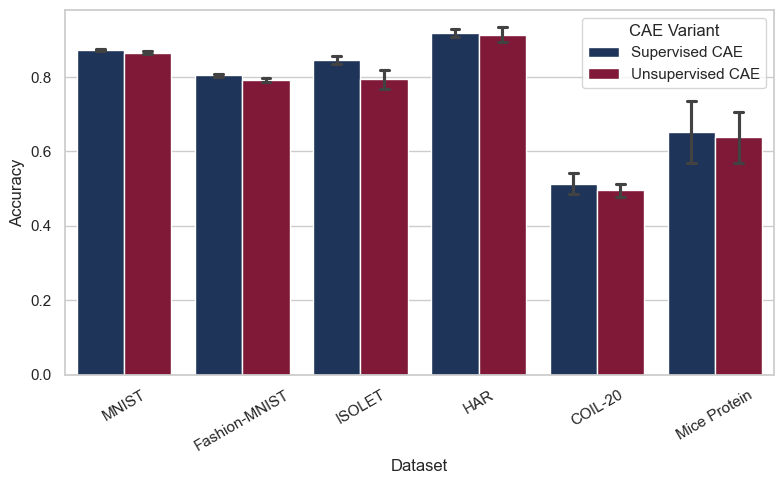

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset order
dataset_order = [
    "mnist",
    "fashion_mnist",
    "isolet",
    "activity",
    "coil20",
    "mice_protein",
]

dataset_labels = {
    "mnist": "MNIST",
    "fashion_mnist": "Fashion-MNIST",
    "isolet": "ISOLET",
    "activity": "HAR",
    "coil20": "COIL-20",
    "mice_protein": "Mice Protein",
}

palette = {
    "unsupervised_cae": "#910730",
    "supervised_cae": "#153163",
}

label_map = {
    "unsupervised_cae": "Unsupervised CAE",
    "supervised_cae": "Supervised CAE",
}

# Apply ordering
df_plot = df.copy()

df_plot["dataset"] = pd.Categorical(
    df_plot["dataset"],
    categories=dataset_order,
    ordered=True,
)

df_plot = df_plot.sort_values("dataset")

# Plot
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df_plot,
    x="dataset",
    y="accuracy",
    hue="subset",
    order=dataset_order,
    palette=palette,
    errorbar="sd",   # standard deviation
    capsize=0.15
)

# Pretty x labels
ax.set_xticklabels(
    [dataset_labels[d] for d in dataset_order],
    rotation=30
)

# Clean legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    [label_map[l] for l in labels],
    title="CAE Variant"
)

ax.set_ylabel("Accuracy")
ax.set_xlabel("Dataset")

plt.tight_layout()
plt.show()

## 5) Plot Reconstruction Error

/var/folders/2d/rgh939n56knbdhv7tklttl740000gn/T/ipykernel_46119/3867377068.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


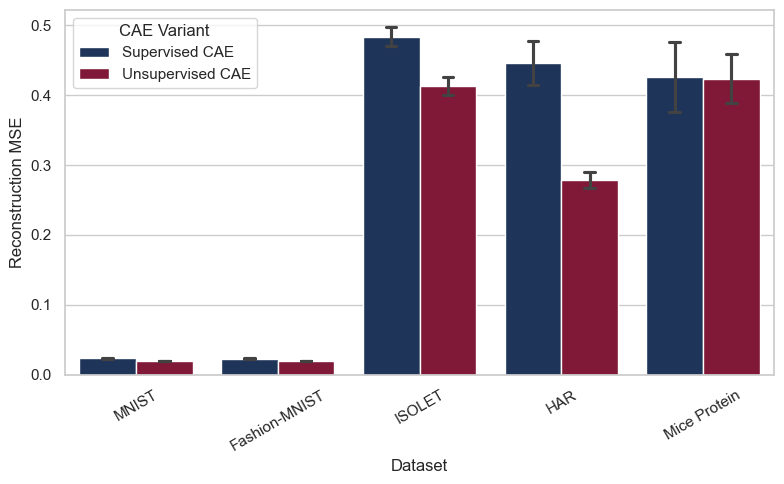

In [20]:
# Remove COIL-20
df_plot = df[df["dataset"] != "coil20"].copy()

dataset_order = [
    "mnist",
    "fashion_mnist",
    "isolet",
    "activity",
    "mice_protein",
]

dataset_labels = {
    "mnist": "MNIST",
    "fashion_mnist": "Fashion-MNIST",
    "isolet": "ISOLET",
    "activity": "HAR",
    "mice_protein": "Mice Protein",
}

palette = {
    "unsupervised_cae": "#910730",
    "supervised_cae": "#153163",
}

label_map = {
    "unsupervised_cae": "Unsupervised CAE",
    "supervised_cae": "Supervised CAE",
}

df_plot["dataset"] = pd.Categorical(
    df_plot["dataset"],
    categories=dataset_order,
    ordered=True,
)

df_plot = df_plot.sort_values("dataset")

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df_plot,
    x="dataset",
    y="reconstruction_mse",
    hue="subset",
    order=dataset_order,
    palette=palette,
    errorbar="sd",
    capsize=0.15,
)

ax.set_xticklabels(
    [dataset_labels[d] for d in dataset_order],
    rotation=30,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    [label_map[l] for l in labels],
    title="CAE Variant",
)

ax.set_ylabel("Reconstruction MSE")
ax.set_xlabel("Dataset")

plt.tight_layout()
plt.show()